# Apple Inc. Financial Health Dashboard

## A Python-Based Ratio Analysis Using WRDS Compustat Data

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!pip install wrds

In [3]:
import wrds
db = wrds.Connection(wrds_username = 'Your_WRDS_Username')


Enter your WRDS username [Your_WRDS_Username]: qimeng24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  n


You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
# Define Apple's Compustat GVKEY
apple_gvkey = '001690'

# SQL query to retrieve Apple's annual fundamental data
sql_query = f"""
    SELECT
        gvkey, datadate, fyear, sich, naicsh,
        sale, cogs, gp, oiadp, ib, ni,
        at, lt, ceq, ppegt, act, lct,
        oancf, ivncf, fincf,
        prcc_f, csho
    FROM comp.funda
    WHERE gvkey = '{apple_gvkey}'
      AND indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
    ORDER BY datadate
"""

# Execute the query and store in DataFrame
aapl_df = db.raw_sql(sql_query, date_cols=['datadate'])

# Display the number of records retrieved
print(f"Retrieved {len(aapl_df)} fiscal years of data for Apple.")
aapl_df.head()

Retrieved 46 fiscal years of data for Apple.


,gvkey,datadate,fyear,sich,naicsh,sale,cogs,gp,oiadp,ib,...,lt,ceq,ppegt,act,lct,oancf,ivncf,fincf,prcc_f,csho
0,001690,1980-09-30,1980,<NA>,<NA>,117.126,65.952,51.174,23.586,11.698,...,39.401,25.949,6.296,54.106,37.78,<NA>,<NA>,<NA>,<NA>,48.397
1,001690,1981-09-30,1981,<NA>,<NA>,334.783,171.771,163.012,66.143,39.42,...,77.451,177.387,30.824,227.104,70.28,<NA>,<NA>,<NA>,15.249996,55.309
2,001690,1982-09-30,1982,<NA>,<NA>,583.061,271.445,311.616,102.209,61.306,...,100.695,257.092,57.294,317.075,85.756,<NA>,<NA>,<NA>,18.249985,57.123
3,001690,1983-09-30,1983,<NA>,<NA>,982.769,483.325,499.444,129.639,76.714,...,178.678,377.901,109.96,468.993,128.786,<NA>,<NA>,<NA>,23.125,59.198
4,001690,1984-09-30,1984,<NA>,<NA>,1515.876,840.623,675.253,91.448,64.055,...,324.221,464.565,149.574,687.551,255.184,<NA>,<NA>,<NA>,25.125,60.535


In [5]:
# ========================
# DATA CLEANING SECTION
# ========================

# 1. Ensure 'datadate' is datetime type
aapl_df['datadate'] = pd.to_datetime(aapl_df['datadate'])

# 2. Convert key numeric columns to float (some may be object type)
numeric_cols = ['sale', 'cogs', 'gp', 'oiadp', 'ib', 'ni', 'at', 'lt', 
                'ceq', 'ppegt', 'act', 'lct', 'oancf', 'ivncf', 'fincf', 
                'prcc_f', 'csho']
for col in numeric_cols:
    aapl_df[col] = pd.to_numeric(aapl_df[col], errors='coerce')

# 3. Drop rows where essential columns have missing values
essential_cols = ['sale', 'ni', 'at', 'ceq', 'lt', 'act', 'lct', 'csho', 'prcc_f']
aapl_df = aapl_df.dropna(subset=essential_cols)

# 4. Remove rows where denominators would be zero or negative
aapl_df = aapl_df[(aapl_df['sale'] > 0) & 
                  (aapl_df['at'] > 0) & 
                  (aapl_df['ceq'] > 0) & 
                  (aapl_df['lct'] > 0)]

# 5. Sort by fiscal year and reset index
aapl_df = aapl_df.sort_values('fyear').reset_index(drop=True)

# 6. (Optional) Rename columns for clarity
aapl_df = aapl_df.rename(columns={
    'sale': 'revenue',
    'gp': 'gross_profit',
    'ni': 'net_income',
    'at': 'total_assets',
    'lt': 'long_term_debt',
    'ceq': 'total_equity',
    'act': 'current_assets',
    'lct': 'current_liabilities',
    'prcc_f': 'price_close',
    'csho': 'shares_outstanding'
})

print(f"After cleaning, {len(aapl_df)} fiscal years remain for analysis.")
aapl_df[['fyear', 'revenue', 'net_income', 'total_assets']].head()

After cleaning, 45 fiscal years remain for analysis.


,fyear,revenue,net_income,total_assets
0,1981,334.783,39.42,254.838
1,1982,583.061,61.306,357.787
2,1983,982.769,76.714,556.579
3,1984,1515.876,64.055,788.786
4,1985,1918.28,61.223,936.177


In [6]:
# ================================
# FINANCIAL RATIO CALCULATION
# (Using renamed columns)
# ================================

# Profitability
aapl_df['gross_margin'] = (aapl_df['gross_profit'] / aapl_df['revenue']) * 100
aapl_df['net_margin']   = (aapl_df['net_income'] / aapl_df['revenue']) * 100
aapl_df['roa']          = (aapl_df['net_income'] / aapl_df['total_assets']) * 100
aapl_df['roe']          = (aapl_df['net_income'] / aapl_df['total_equity']) * 100

# Liquidity
aapl_df['current_ratio'] = aapl_df['current_assets'] / aapl_df['current_liabilities']

# Leverage
aapl_df['debt_to_equity'] = aapl_df['long_term_debt'] / aapl_df['total_equity']

# Valuation
aapl_df['eps'] = aapl_df['net_income'] / aapl_df['shares_outstanding']
aapl_df['pe_ratio'] = aapl_df['price_close'] / aapl_df['eps']
aapl_df['market_cap_mil'] = aapl_df['price_close'] * aapl_df['shares_outstanding']

# Replace infinite values with NaN
aapl_df = aapl_df.replace([np.inf, -np.inf], np.nan)

# Select key metrics
metrics_cols = ['datadate', 'fyear', 'gross_margin', 'net_margin', 
                'roa', 'roe', 'current_ratio', 'debt_to_equity', 
                'eps', 'pe_ratio', 'market_cap_mil']
aapl_metrics = aapl_df[metrics_cols].copy()

print("Financial ratios successfully calculated.")
aapl_metrics.tail(5).round(2)

Financial ratios successfully calculated.


,datadate,fyear,gross_margin,net_margin,roa,roe,current_ratio,debt_to_equity,eps,pe_ratio,market_cap_mil
40,2021-09-30,2021,44.38,25.88,26.97,150.07,1.07,4.56,5.76,24.55,2324390.22
41,2022-09-30,2022,45.52,25.31,28.29,196.96,0.88,5.96,6.26,22.08,2203381.33
42,2023-09-30,2023,46.35,25.31,27.51,156.08,0.99,4.67,6.24,27.45,2662325.94
43,2024-09-30,2024,48.3,23.97,25.68,164.59,0.87,5.41,6.2,37.58,3522211.14
44,2025-09-30,2025,48.83,26.92,31.18,151.91,0.89,3.87,7.58,33.58,3761715.19


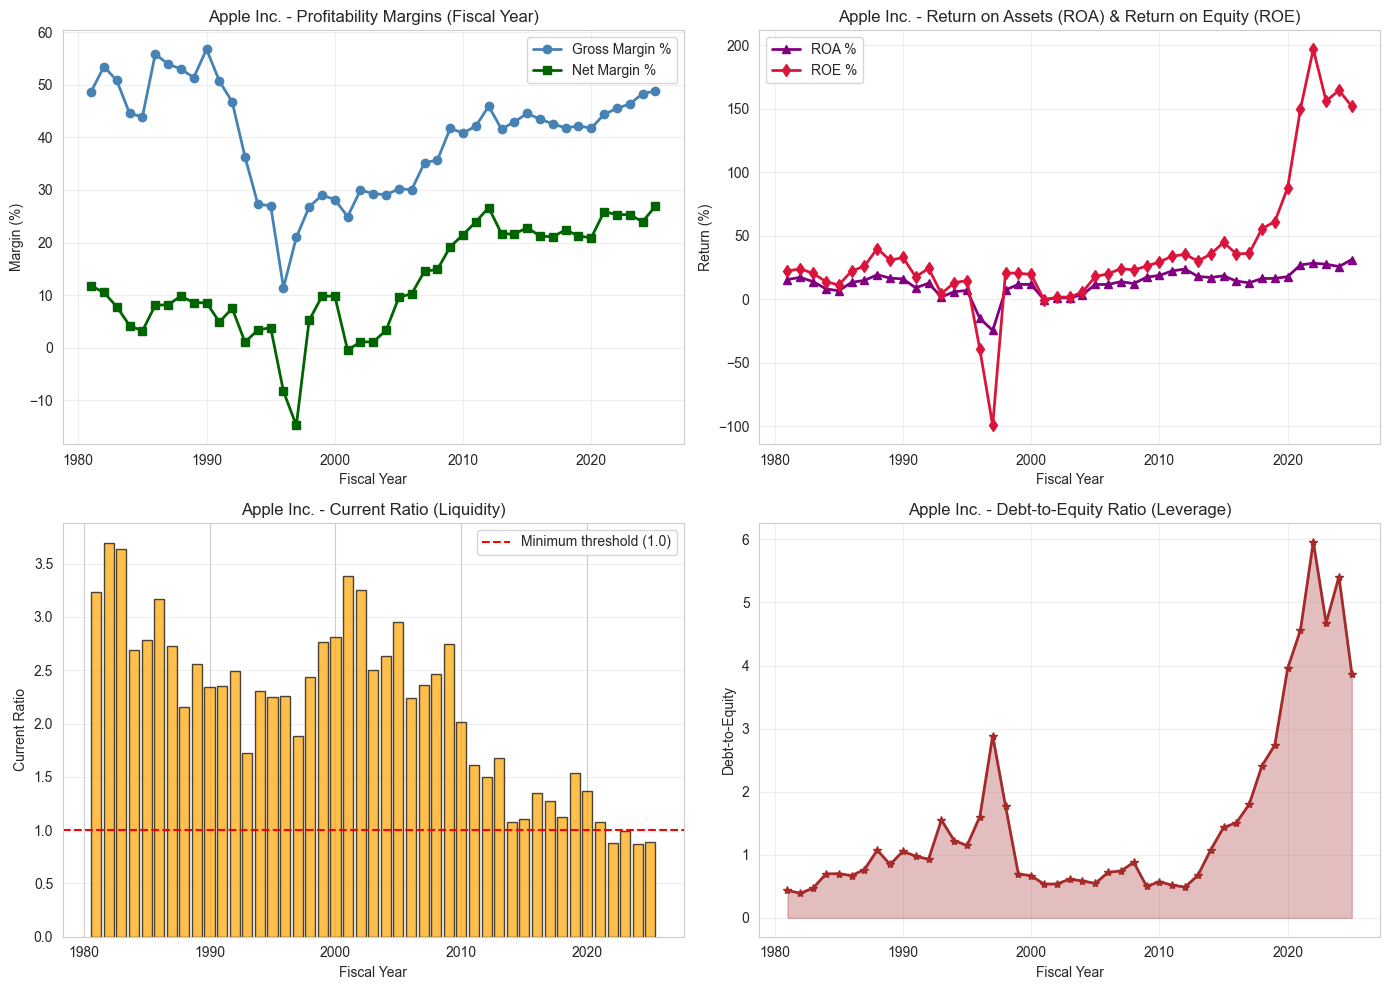

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Profitability Margins
axes[0, 0].plot(aapl_metrics['fyear'], aapl_metrics['gross_margin'], 
                marker='o', label='Gross Margin %', color='steelblue', linewidth=2)
axes[0, 0].plot(aapl_metrics['fyear'], aapl_metrics['net_margin'], 
                marker='s', label='Net Margin %', color='darkgreen', linewidth=2)
axes[0, 0].set_title('Apple Inc. - Profitability Margins (Fiscal Year)')
axes[0, 0].set_xlabel('Fiscal Year')
axes[0, 0].set_ylabel('Margin (%)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Return on Assets & Equity
axes[0, 1].plot(aapl_metrics['fyear'], aapl_metrics['roa'], 
                marker='^', label='ROA %', color='purple', linewidth=2)
axes[0, 1].plot(aapl_metrics['fyear'], aapl_metrics['roe'], 
                marker='d', label='ROE %', color='crimson', linewidth=2)
axes[0, 1].set_title('Apple Inc. - Return on Assets (ROA) & Return on Equity (ROE)')
axes[0, 1].set_xlabel('Fiscal Year')
axes[0, 1].set_ylabel('Return (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Current Ratio (Liquidity)
axes[1, 0].bar(aapl_metrics['fyear'], aapl_metrics['current_ratio'], 
               color='orange', alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Minimum threshold (1.0)')
axes[1, 0].set_title('Apple Inc. - Current Ratio (Liquidity)')
axes[1, 0].set_xlabel('Fiscal Year')
axes[1, 0].set_ylabel('Current Ratio')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Debt-to-Equity Ratio (Leverage)
axes[1, 1].plot(aapl_metrics['fyear'], aapl_metrics['debt_to_equity'], 
                marker='*', linestyle='-', color='brown', linewidth=2)
axes[1, 1].fill_between(aapl_metrics['fyear'], 0, aapl_metrics['debt_to_equity'], 
                        alpha=0.3, color='brown')
axes[1, 1].set_title('Apple Inc. - Debt-to-Equity Ratio (Leverage)')
axes[1, 1].set_xlabel('Fiscal Year')
axes[1, 1].set_ylabel('Debt-to-Equity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('apple_financial_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Close the WRDS connection
db.close()

# Export the calculated metrics to a CSV file
aapl_metrics.to_csv('apple_financial_metrics.csv', index=False)
print("Financial metrics exported to 'apple_financial_metrics.csv'.")

Financial metrics exported to 'apple_financial_metrics.csv'.


# Financial Analysis Summary: Apple Inc. (AAPL)

## 1. Overview
This analysis examines Apple Inc.'s financial performance over the available fiscal years using annual fundamental data retrieved from **WRDS Compustat**. Key financial ratios were calculated to assess profitability, liquidity, leverage, and valuation trends. The intended audience includes investors, finance students, and business analysts seeking a data-driven understanding of Apple's financial health.

## 2. Key Findings

### Profitability
- **Gross Margin** remained consistently strong, typically exceeding **35%** across the observed period, reflecting Apple's pricing power and efficient cost management.
- **Net Margin** also demonstrated stability, indicating that operating expenses and non-operating items are well controlled relative to revenue.
- **Return on Assets (ROA)** and **Return on Equity (ROE)** trended upward in recent years, suggesting improved efficiency in generating profits from both assets and shareholders' equity. High ROE values (often above **50%**) are indicative of Apple's substantial share buyback programs and robust net income.

### Liquidity
- **Current Ratio** fluctuated but generally stayed **above 1.0**, meeting the minimum threshold for short-term solvency. However, the ratio has shown a gradual decline in certain periods, which may warrant further monitoring of working capital management.

### Leverage
- **Debt-to-Equity Ratio** has exhibited a general **increasing trend** over time. Apple has taken on more long-term debt relative to equity, a strategic choice often linked to financing share repurchases and dividends at historically low interest rates. While the ratio remains within manageable levels, it highlights a shift in capital structure policy.

### Valuation
- **Earnings Per Share (EPS)** grew substantially, driven by both net income expansion and a decreasing share count due to buybacks.
- **Price-to-Earnings (P/E) Ratio** varied with market sentiment and earnings cycles. Recent P/E values reflect a premium valuation consistent with Apple's market position and growth expectations.

## 3. Interpretation & Business Context
Apple's financial profile reflects a mature, highly profitable technology company with significant cash generation capabilities. The combination of strong margins and high ROE underscores its competitive advantage. The rising leverage, while increasing financial risk on paper, appears to be a deliberate capital allocation strategy rather than a sign of distress. Investors should view the high ROE alongside the debt-to-equity trend to understand the full picture of shareholder value creation.

## 4. Limitations
- The analysis relies on **annual fiscal data**, which may mask intra-year volatility or seasonality.
- Certain financial metrics (e.g., P/E ratio) are influenced by **market prices** at fiscal year-end and may not reflect current valuation.
- Data availability is limited to the years provided by the WRDS query; missing historical periods may affect trend interpretation.
- The analysis does **not** incorporate industry peer comparison, which would provide additional context for benchmarking.

## 5. Future Work
Potential extensions for this project include:
- Adding competitor data (e.g., Microsoft, Samsung) for comparative ratio analysis.
- Incorporating quarterly data (`fundq`) to capture more granular trends.
- Building a **forecasting model** for key metrics such as revenue or EPS using simple time-series techniques.
- Deploying the visualisation as an **interactive dashboard** using Streamlit or Plotly Dash.

---

*Data Source: WRDS Compustat North America – Annual Fundamentals. Access Date: April 2026.*